# **Instalação dos pacotes necessários**

---



In [30]:
!pip install spacy -q
!python -m spacy download pt_core_news_sm -q
!pip install gensim -q
!pip install hdbscan -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 60.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [31]:
import numpy as np
import pandas as pd
import json
import requests
import unicodedata
import re
import nltk
import spacy
import random
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB, GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, fbeta_score, classification_report, confusion_matrix
from sklearn.manifold import MDS
from matplotlib.colors import ListedColormap, BoundaryNorm
from gensim.models import Word2Vec
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('rslp', quiet=True)
nlp = spacy.load("pt_core_news_sm")

# **Importação da base de dados**

---



In [32]:
# Importação da base de atas
base_data_url = 'https://raw.githubusercontent.com/moreirapauloas/exercicios_nlp/main/base_nlp_final.json'

response = requests.get(base_data_url)
data = response.json()

df = pd.DataFrame(data)
df['texto'] = df['texto'].fillna('').astype(str)

print(df.shape)

(374, 5)


In [33]:
# Explosão dos textos de cada elemento por linha de texto
df['texto'] = df['texto'].str.split('\n')
df_explodido = df.explode('texto')
df_explodido['texto'] = df_explodido['texto'].str.strip()
df_explodido = df_explodido[df_explodido['texto'] != '']
df_explodido = df_explodido.reset_index(drop=True)
df_explodido['texto'] = df_explodido['texto'].str.replace('\u000b', ' ', regex=False)
print(df_explodido.shape)

(6480, 5)


In [34]:
# Limpeza grossa da base de dados
NOISE_PATTERNS = [
    r'^\s*$',
    r'^\s*[-+!:\.;]+\s*$',

    # boilerplate
    r'(?i)^lembrete:?',
    r'(?i)^ao atualizar',
    r'(?i)^entregas significativas',
    r'(?i)^entregas siginificativas',
    r'(?i)^caso não tenha nenhuma inserir',
    r'(?i)^caso nao tenha nenhuma inserir',

    # headings
    r'(?i)^síntese',
    r'(?i)^sintese',
    r'(?i)^status:',
    r'(?i)^responsável:',
    r'(?i)^responsáveis:',

    # leakage
    r'(?i)^pontos positivos',
    r'(?i)^pontos negativos',
    r'(?i)^pontos de atenção',
    r'(?i)^próximos passos',
    r'(?i)^proximos passos',

    # placeholders
    r'(?i)^n/?a$',
    r'(?i)^não existe$',
    r'(?i)^nao existe$',

    # pure metadata
    r'(?i)^pessoa\s+\w+:\s*(atualizado|desatualizado)$',
]


def clean_text_line(text):
    if pd.isna(text):
        return None

    text = str(text)

    # normalização
    text = text.replace('\u000b', ' ')
    text = text.replace('\xa0', ' ')
    text = re.sub(r'\s+', ' ', text).strip()

    # bullets
    text = re.sub(r'^[-•*]+\s*', '', text)

    # prefixes
    text = re.sub(r'^(?:[:;\-–—]+\s*)+', '', text)

    # P.P / P.A
    text = re.sub(r'(?i)^p\.p\.\s*', '', text)
    text = re.sub(r'(?i)^p\.a\.\s*', '', text)

    # PP sem pontuação
    text = re.sub(r'(?i)^pp\s+', '', text)

    # numbering
    text = re.sub(r'^\d+\s*[-.:)]\s*', '', text)

    # remove caracteres estranhos
    text = text.replace('\u000b', ' ')

    # remove prefixos decorativos
    text = re.sub(r'^\s*[:;\-–—]+\s*', '', text)

    # remove colchetes mantendo conteúdo
    # [Projeto P47] -> Projeto P47
    text = re.sub(r'\[(.*?)\]', r'\1', text)

    # normaliza espaços
    text = re.sub(r'\s+', ' ', text).strip()

    for pattern in NOISE_PATTERNS:
        if re.search(pattern, text):
            return None

    # muito curto = geralmente ruído
    if len(text) < 25:
        return None

    # muito poucas palavras = ruído
    if len(text.split()) < 4:
        return None

    return text

df_explodido['texto'] = df_explodido['texto'].apply(clean_text_line)
df_explodido = df_explodido.dropna(subset=['texto']).reset_index(drop=True)

print(df_explodido.shape)

(3603, 5)


# **Pré-processamento da base**

---



In [35]:
# Funções de pré-processamento dos textos
def case_folding(text):
  'Função para execução de case folding'
  if pd.isna(text):
    return ''

  text = text.lower()
  return text

def remove_accents_nfkd(text):
  'Função para remoção de acentos'
  if not text:
    return ''
  text_nfkd = unicodedata.normalize('NFKD', text)
  return "".join(char for char in text_nfkd if not unicodedata.combining(char))

def clean_punctuation_and_tags(text):
  'Função para remoção de pontuações e tags'
  if not text:
    return ''

  text = re.sub(r'<[^>]+>', ' ', text)
  text = re.sub(r'[^\w\s&$]', ' ', text)
  text = re.sub(r'_+', ' ', text)
  text = re.sub(r'\s+', ' ', text).strip()

  return text

def tokenize(text):
  'Função para tokenização'
  if not text:
    return ""

  tokens = text.split()
  return tokens

def remove_stopwords(tokens):
  'Função para remoção de stopwords'
  stop_words = set(stopwords.words('portuguese'))

  return [word for word in tokens if word not in stop_words]

def apply_lemmatization(text):
  'Função para lemmatização'
  doc = nlp(text)
  return [token.lemma_ for token in doc]

def pipeline_preprocessing(text):
  'Função para aplicação do pipeline de pré-processamento completo'
  if not isinstance(text, str):
      text = str(text)

  processed_text = case_folding(text)
  processed_text = remove_accents_nfkd(processed_text)
  processed_text = clean_punctuation_and_tags(processed_text)

  tokens = tokenize(processed_text)
  tokens = remove_stopwords(tokens)

  text_for_lemmatization = " ".join(tokens)
  lemma = apply_lemmatization(text_for_lemmatization)

  return {
      'lemma': lemma,
      'docs_lemma': " ".join(lemma)
  }

In [36]:
# Aplicação do pipeline de pré-processamento
result = df_explodido['texto'].apply(pipeline_preprocessing)

df_lemmas = pd.DataFrame(result.tolist())

df_result = pd.concat([df_explodido.reset_index(drop=True),
                       df_lemmas.reset_index(drop=True)], axis=1)

# Ajuste dos meses dos itens para número
MESES_PT = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4,
    'maio': 5, 'junho': 6, 'julho': 7, 'agosto': 8,
    'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12
}

df_result['mes_num'] = df_result['mes'].str.strip().str.lower().map(MESES_PT)

# Formatação do período dos itens para formato mês e ano
df_result['periodo'] = pd.to_datetime(
    df_result['ano'].astype(str) + '-' +
    df_result['mes_num'].astype(str).str.zfill(2),
    format='%Y-%m',
    errors='coerce'
)

docs_tokens = df_result['lemma']
docs_text = [" ".join(tokens) for tokens in df_result['lemma']]
print(df_result.shape)

(3603, 9)


# **Funções de vetorização**

---



In [37]:
class Word2VecVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=300, window=5, min_count=2, workers=4):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.model = None

    def fit(self, X, y=None):
        tokenized = [text.split() for text in X]
        self.model = Word2Vec(
            sentences=tokenized,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers
        )
        return self

    def transform(self, X):
        tokenized = [text.split() for text in X]
        vectors = []

        for tokens in tokenized:
            word_vecs = [
                self.model.wv[word]
                for word in tokens
                if word in self.model.wv
            ]

            if len(word_vecs) == 0:
                vectors.append(np.zeros(self.vector_size))
            else:
                vectors.append(np.mean(word_vecs, axis=0))

        return np.array(vectors)

In [38]:
_BERT_MODEL = None

class BertVectorizer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        model_name='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
    ):
        self.model_name = model_name

    def _get_model(self):
        global _BERT_MODEL

        if _BERT_MODEL is None:
            _BERT_MODEL = SentenceTransformer(self.model_name)

        return _BERT_MODEL

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        model = self._get_model()

        return model.encode(
            X.tolist(),
            batch_size=32,
            show_progress_bar=False
        )

# **Classificação de problema x não problema**

---



In [39]:
#Importação do dataset de treino
train_data_url = 'https://raw.githubusercontent.com/moreirapauloas/exercicios_nlp/main/dataset treino nlp.json'
response = requests.get(train_data_url)
dataset = response.json()
df_treino = pd.DataFrame(dataset, columns=['texto', 'label', 'origem', 'confianca'])

#X_treino = df_treino[df_treino['origem'] == 'real']['texto']
#y_treino = df_treino[df_treino['origem'] == 'real']['label']

X_treino = df_treino['texto']
y_treino = df_treino['label']

def preprocessar_para_classificador(texto):
  """
  Pré-processamento leve para o classificador SVM/NB.
  Mais conservador que o pipeline completo - preserva
  sinais importantes como P.A., P.P. e nomes de projetos.
  """
  if not isinstance(texto, str):
    return ""
  tokens = pipeline_preprocessing(texto)['lemma']
  return " ".join(tokens)

In [40]:
#Seleção das variáveis de treino e teste
y = df_treino['label']
X_raw   = df_treino['texto']
X_lemma = df_treino['texto'].apply(preprocessar_para_classificador)

#Splittar usando índices compartilhados
from sklearn.model_selection import train_test_split

idx = np.arange(len(df_treino))
idx_treino, idx_teste = train_test_split(
    idx, test_size=0.20, stratify=y, random_state=42
)

X_treino_raw   = X_raw.iloc[idx_treino].reset_index(drop=True)
X_teste_raw    = X_raw.iloc[idx_teste].reset_index(drop=True)

X_treino_lemma = X_lemma.iloc[idx_treino].reset_index(drop=True)
X_teste_lemma  = X_lemma.iloc[idx_teste].reset_index(drop=True)

y_treino = y.iloc[idx_treino].reset_index(drop=True)
y_teste  = y.iloc[idx_teste].reset_index(drop=True)

#Mapeamento por vetorizador
X_por_vetorizacao = {
    'BERT'  : X_treino_raw,
    'TF-IDF': X_treino_raw,
    'W2V'   : X_treino_raw,
}

X_teste_por_vetorizacao = {
    'BERT'  : X_teste_raw,
    'TF-IDF': X_teste_raw,
    'W2V'   : X_teste_raw,
}

In [41]:
# Treinamento da classificação em problema x não problema
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

metricas = {
    'f2': make_scorer(fbeta_score, beta=2, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
}

# Definição dos pipelines
modelos = {
    ('SVM', 'TF-IDF'): Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 3))),
        ('clf', LinearSVC(C=1.0, class_weight='balanced', random_state=42))
    ]),

    ('SVM', 'W2V'): Pipeline([
        ('w2v', Word2VecVectorizer()),
        ('clf', LinearSVC(C=1.0, class_weight='balanced', random_state=42))
    ]),

    ('SVM', 'BERT'): Pipeline([
        ('bert', BertVectorizer()),
        ('clf', LinearSVC(C=1.0, class_weight='balanced', random_state=42))
    ]),

    ('Naive Bayes', 'TF-IDF'): Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 3))),
        ('clf', ComplementNB())
    ]),

    ('Naive Bayes', 'W2V'): Pipeline([
        ('w2v', Word2VecVectorizer()),
        ('clf', GaussianNB())
    ]),

    ('Naive Bayes', 'BERT'): Pipeline([
        ('bert', BertVectorizer()),
        ('clf', GaussianNB())
    ]),

    ('Random Forest', 'TF-IDF'): Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 3))),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    ('Random Forest', 'W2V'): Pipeline([
        ('w2v', Word2VecVectorizer()),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=1
        ))
    ]),

    ('Random Forest', 'BERT'): Pipeline([
        ('bert', BertVectorizer()),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# Avaliação
def avaliar_modelo(pipeline, X, y):
    resultados = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=metricas,
        n_jobs=1,
        return_train_score=False
    )

    return {
        'F2': resultados['test_f2'].mean(),
        'F1': resultados['test_f1'].mean(),
        'Precision': resultados['test_precision'].mean(),
        'Recall': resultados['test_recall'].mean(),
        'F2_STD': resultados['test_f2'].std()
    }

# Benchmark
resultados_benchmark = []

for (classificador, vetorizacao), pipeline in modelos.items():
    print(f"Avaliando {classificador} + {vetorizacao}...")

    X = X_por_vetorizacao[vetorizacao]

    resultado = avaliar_modelo(pipeline, X, y_treino)

    resultados_benchmark.append({
        'Classificador': classificador,
        'Vetorização': vetorizacao,
        'F2': resultado['F2'],
        'F1': resultado['F1'],
        'Precision': resultado['Precision'],
        'Recall': resultado['Recall'],
        'F2_STD': resultado['F2_STD'],
        'Pipeline': pipeline
    })

df_resultados = pd.DataFrame(resultados_benchmark)

Avaliando SVM + TF-IDF...
Avaliando SVM + W2V...
Avaliando SVM + BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Avaliando Naive Bayes + TF-IDF...
Avaliando Naive Bayes + W2V...
Avaliando Naive Bayes + BERT...
Avaliando Random Forest + TF-IDF...
Avaliando Random Forest + W2V...
Avaliando Random Forest + BERT...


In [42]:
# Matriz de avaliação dos modelos
matriz_precision = df_resultados.pivot(
    index='Classificador',
    columns='Vetorização',
    values='F1'
)

print("\nMATRIZ COMPARATIVA (F1)")
print("=" * 60)
print(matriz_precision.round(3))

# Seleção do melhor modelo
melhor_modelo = df_resultados.loc[
    df_resultados['F1'].idxmax()
]

print("\nMELHOR COMBINAÇÃO")
print("=" * 60)
print(f"Classificador : {melhor_modelo['Classificador']}")
print(f"Vetorização   : {melhor_modelo['Vetorização']}")
print(f"F1 Score      : {melhor_modelo['F1']:.3f}")
print(f"Recall        : {melhor_modelo['Recall']:.3f}")
print(f"Precision     : {melhor_modelo['Precision']:.3f}")

modelo_final = melhor_modelo['Pipeline']
vetorizacao_final = melhor_modelo['Vetorização']

X_treino_final = X_por_vetorizacao[vetorizacao_final]
X_teste_final  = X_teste_por_vetorizacao[vetorizacao_final]

modelo_final.fit(X_treino_final, y_treino)

y_pred = modelo_final.predict(X_teste_final)

print("\nAVALIAÇÃO NO TEST SET")
print("=" * 60)
print(classification_report(y_teste, y_pred,zero_division=0))
print("\nCONFUSION MATRIX")
print("=" * 60)
print(confusion_matrix(y_teste,y_pred))


MATRIZ COMPARATIVA (F1)
Vetorização     BERT  TF-IDF    W2V
Classificador                      
Naive Bayes    0.719   0.716  0.479
Random Forest  0.699   0.736  0.308
SVM            0.798   0.811  0.357

MELHOR COMBINAÇÃO
Classificador : SVM
Vetorização   : TF-IDF
F1 Score      : 0.811
Recall        : 0.805
Precision     : 0.818

AVALIAÇÃO NO TEST SET
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       317
           1       0.86      0.89      0.87       160

    accuracy                           0.91       477
   macro avg       0.90      0.91      0.90       477
weighted avg       0.91      0.91      0.91       477


CONFUSION MATRIX
[[294  23]
 [ 18 142]]


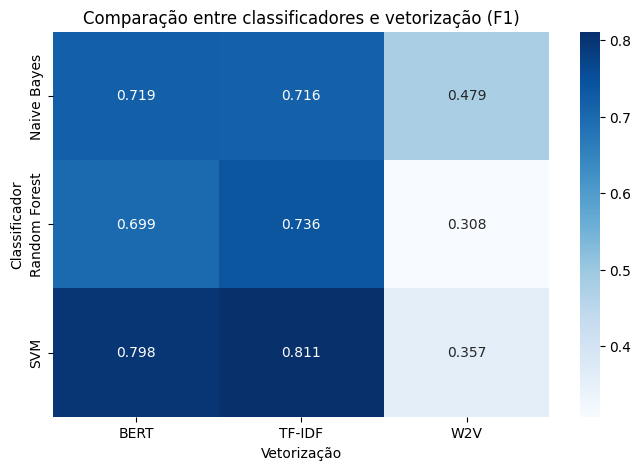

In [43]:
# Avaliação dos modelos por mapa de calor
plt.figure(figsize=(8, 5))
sns.heatmap(matriz_precision, annot=True, fmt=".3f", cmap="Blues")
plt.title("Comparação entre classificadores e vetorização (F1)")
plt.show()


In [44]:
resultados_teste = []

for (classificador, vetorizacao), pipeline in modelos.items():

    print(f"Treinando {classificador} + {vetorizacao}")

    X_train = X_por_vetorizacao[vetorizacao]
    X_test  = X_teste_por_vetorizacao[vetorizacao]

    # treino
    pipeline.fit(X_train, y_treino)

    # predição
    y_pred = pipeline.predict(X_test)

    # métricas
    resultados_teste.append({
        'Classificador': classificador,
        'Vetorização': vetorizacao,
        'F1': f1_score(y_teste, y_pred, zero_division=0),
        'Precision': precision_score(y_teste, y_pred, zero_division=0),
        'Recall': recall_score(y_teste, y_pred, zero_division=0),
        'F2': fbeta_score(y_teste, y_pred, beta=2, zero_division=0)
    })

df_resultados_teste = pd.DataFrame(resultados_teste)

Treinando SVM + TF-IDF
Treinando SVM + W2V
Treinando SVM + BERT
Treinando Naive Bayes + TF-IDF
Treinando Naive Bayes + W2V
Treinando Naive Bayes + BERT
Treinando Random Forest + TF-IDF
Treinando Random Forest + W2V
Treinando Random Forest + BERT


In [45]:
matriz_precision = df_resultados_teste.pivot(
    index='Classificador',
    columns='Vetorização',
    values='F1'
)

print("\nMATRIZ COMPARATIVA (F1)")
print("=" * 60)
print(matriz_precision.round(3))


MATRIZ COMPARATIVA (F1)
Vetorização     BERT  TF-IDF    W2V
Classificador                      
Naive Bayes    0.727   0.730  0.483
Random Forest  0.775   0.823  0.276
SVM            0.816   0.874  0.399


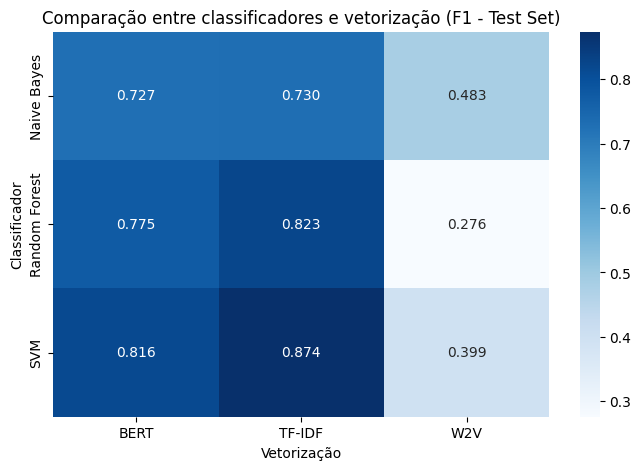

In [46]:
plt.figure(figsize=(8,5))
sns.heatmap(
    matriz_precision,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)
plt.title("Comparação entre classificadores e vetorização (F1 - Test Set)")
plt.show()

In [47]:
def encontrar_threshold_otimo(pipeline, X, y, cv, metrica='f1', recall_minimo=0.65):
    todos_scores = []
    todos_labels = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)

        if hasattr(pipeline, "decision_function"):
            scores = pipeline.decision_function(X_val)
        else:
            scores = pipeline.predict_proba(X_val)[:, 1]

        todos_scores.extend(scores)
        todos_labels.extend(y_val)

    todos_scores = np.array(todos_scores)
    todos_labels = np.array(todos_labels)

    thresholds = np.percentile(todos_scores, np.arange(10, 91, 2))

    melhor_threshold = None
    melhor_valor     = -1
    melhor_recall    = -1

    for t in thresholds:
        preds = (todos_scores >= t).astype(int)
        rec   = recall_score(todos_labels, preds, zero_division=0)

        if rec < recall_minimo:
            continue

        if metrica == 'f1':
            valor = f1_score(todos_labels, preds, zero_division=0)
        elif metrica == 'precision':
            valor = precision_score(todos_labels, preds, zero_division=0)
        elif metrica == 'f2':
            valor = fbeta_score(todos_labels, preds, beta=2, zero_division=0)

        if valor > melhor_valor:
            melhor_valor     = valor
            melhor_threshold = t
            melhor_recall    = rec

    # Fallback: se nenhum threshold atingiu o recall_minimo, avisa e usa o mais baixo
    if melhor_threshold is None:
        print(f"⚠️  Nenhum threshold atingiu recall_minimo={recall_minimo}.")
        print(f"    Tente reduzir recall_minimo. Usando threshold mais permissivo.")
        melhor_threshold = thresholds[0]
        preds            = (todos_scores >= melhor_threshold).astype(int)
        melhor_recall    = recall_score(todos_labels, preds, zero_division=0)
        melhor_valor     = f1_score(todos_labels, preds, zero_division=0)

    return melhor_threshold, melhor_valor, melhor_recall


threshold_otimo, valor_otimo, recall_otimo = encontrar_threshold_otimo(
    modelo_final, X_treino_final, y_treino, cv,
    metrica='f1',
    recall_minimo=0.75
)

print(f"Threshold otimizado : {threshold_otimo:.4f}")
print(f"F1 otimizado        : {valor_otimo:.3f}")
print(f"Recall otimizado    : {recall_otimo:.3f}")

Threshold otimizado : -0.0090
F1 otimizado        : 0.812
Recall otimizado    : 0.816


In [48]:
# Classificação do corpus real
classification_threshold = threshold_otimo

def classificar_com_threshold(X, modelo, threshold=classification_threshold):
    """
    Classificação genérica compatível com:
    - LinearSVC (decision_function)
    - Naive Bayes / RF (predict_proba)
    - fallback predict()
    """
    if hasattr(modelo, "decision_function"):
        scores = modelo.decision_function(X)
        return (scores >= threshold).astype(int)
    elif hasattr(modelo, "predict_proba"):
        probs = modelo.predict_proba(X)[:, 1]
        return (probs >= threshold).astype(int)
    else:
        return modelo.predict(X)

if vetorizacao_final == 'BERT':
    X_real = df_result['texto']
else:
    # pipelines textuais continuam recebendo texto
    X_real = df_result['texto']

df_result['eh_problema'] = classificar_com_threshold(
    X_real,
    modelo_final,
    threshold=classification_threshold
)

df_so_problemas = df_result[
    df_result['eh_problema'] == 1
].reset_index(drop=True)

df_nao_problemas = df_result[
    df_result['eh_problema'] == 0
].reset_index(drop=True)


print("\nRESULTADO DA CLASSIFICAÇÃO")
print("=" * 60)
print(f"Threshold utilizado: {classification_threshold}")
print(f"Segmentos classificados como PROBLEMA    : {len(df_so_problemas)}")
print(f"Segmentos classificados como NÃO-PROBLEMA: {len(df_nao_problemas)}")


RESULTADO DA CLASSIFICAÇÃO
Threshold utilizado: -0.008950575387836838
Segmentos classificados como PROBLEMA    : 945
Segmentos classificados como NÃO-PROBLEMA: 2658


In [49]:
print(df_treino['label'].value_counts())
print(df_treino['label'].value_counts(normalize=True).round(3))
print(f"\nTotal treino: {len(df_treino)}")
print(f"Total corpus real: {len(df_result)}")


label
0    1582
1     802
Name: count, dtype: int64
label
0    0.664
1    0.336
Name: proportion, dtype: float64

Total treino: 2384
Total corpus real: 3603


Scores reais — min: -1.251 | max: 1.559 | média: -0.295
Threshold: -0.0090
% acima do threshold: 26.2%


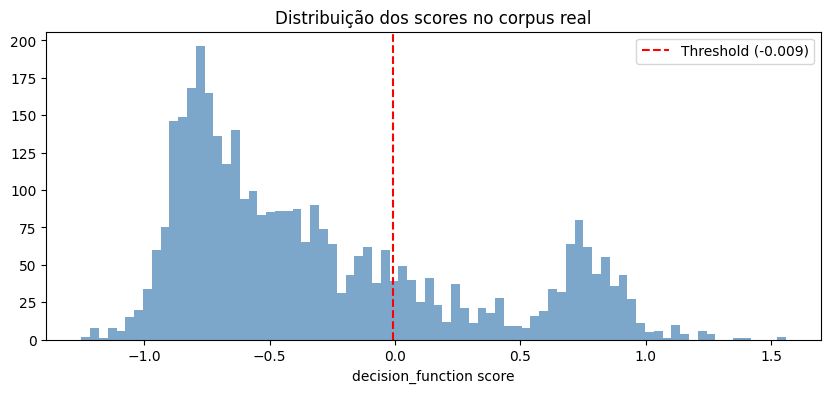

In [50]:
scores_real = modelo_final.decision_function(X_real)

print(f"Scores reais — min: {scores_real.min():.3f} | max: {scores_real.max():.3f} | média: {scores_real.mean():.3f}")
print(f"Threshold: {threshold_otimo:.4f}")
print(f"% acima do threshold: {(scores_real >= threshold_otimo).mean():.1%}")

# Histograma dos scores
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.hist(scores_real, bins=80, color='steelblue', alpha=0.7)
plt.axvline(threshold_otimo, color='red', linestyle='--', label=f'Threshold ({threshold_otimo:.3f})')
plt.title('Distribuição dos scores no corpus real')
plt.xlabel('decision_function score')
plt.legend()
plt.show()


# **Agrupamento dos problemas**

---



In [51]:
# Vetorização dos problemas para agrupamento
model_s2v = SentenceTransformer(
    'paraphrase-multilingual-MiniLM-L12-v2'
)

vetores_problemas = model_s2v.encode(
    df_so_problemas['texto'].tolist(),
    convert_to_numpy=True
)

vetores_problemas = normalize(vetores_problemas)

print(f"Shape dos vetores: {vetores_problemas.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Shape dos vetores: (945, 384)


In [52]:
# Agrupamento Semântico com HDBSCAN
# Para aplicação do HDBSCAN, é utilizada uma métrica de distância semântica, e
# distância de tempo, pois problemas que possam parecer similares, mas que tem um
# intervalo de tempo muito grande de aparição, provavelmente não são o mesmo problema.
temporal_weight = 0.25
gap_max_meses = 10

periodos_num = (
    df_so_problemas['ano'].astype(float) * 12 +
    df_so_problemas['mes_num'].astype(float)
).values

mediana_periodo = np.nanmedian(periodos_num)
periodos_num = np.where(np.isnan(periodos_num), mediana_periodo, periodos_num)

dist_semantica = cosine_distances(vetores_problemas)

n = len(periodos_num)
dist_temporal = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        gap = abs(periodos_num[i] - periodos_num[j])
        dist_temporal[i, j] = min(gap / gap_max_meses, 1.0)

dist_combinada = (1 - temporal_weight) * dist_semantica + temporal_weight * dist_temporal
dist_combinada = (dist_combinada + dist_combinada.T) / 2
np.fill_diagonal(dist_combinada, 0.0)

# Aplicação de HDBSCAN para geração dos clusters
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4,
    min_samples=3,
    metric='precomputed',
    cluster_selection_method='eom'
)

labels = clusterer.fit_predict(dist_combinada)

df_so_problemas['cluster'] = labels
df_so_problemas['cluster_prob'] = clusterer.probabilities_

min_cluster_prob = 0.50

df_so_problemas.loc[df_so_problemas['cluster_prob'] < min_cluster_prob, 'cluster'] = -1

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido = (labels == -1).sum()

print(f"Clusters encontrados : {n_clusters}")
print(f"Problemas agrupados  : {len(df_so_problemas) - n_ruido} ({100*(len(df_so_problemas)-n_ruido)/len(df_so_problemas):.1f}%)")
print(f"Problemas isolados   : {n_ruido} (sem par semântico)")


Clusters encontrados : 57
Problemas agrupados  : 334 (35.3%)
Problemas isolados   : 611 (sem par semântico)


In [53]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy

print("=" * 60)
print("MÉTRICAS DE AVALIAÇÃO DO CLUSTERING")
print("=" * 60)

# ── Preparação ────────────────────────────────────────────────────────────────
# Usa cluster pós-filtro de min_cluster_prob (já aplicado no df_so_problemas)
mask_validos       = df_so_problemas['cluster'] != -1
vetores_validos    = vetores_problemas[mask_validos.values]   # array numpy
labels_validos     = df_so_problemas.loc[mask_validos, 'cluster'].values
dist_valida        = dist_combinada[np.ix_(mask_validos.values, mask_validos.values)]

n_clusters_val = len(np.unique(labels_validos))
n_ruido_val    = (~mask_validos).sum()
n_total        = len(df_so_problemas)

# ── 1. Proporção de ruído ─────────────────────────────────────────────────────
# Ideal: < 30%. Alto ruído indica min_cluster_size muito restritivo.
pct_ruido = n_ruido_val / n_total
print(f"\nClusters formados       : {n_clusters_val}")
print(f"Problemas agrupados     : {mask_validos.sum()} ({1 - pct_ruido:.1%})")
print(f"Problemas isolados      : {n_ruido_val} ({pct_ruido:.1%})  [ideal < 30%]")

# ── 2. Silhouette Score ───────────────────────────────────────────────────────
# Mede coesão interna e separação entre clusters.
# Escala: -1 a +1. Acima de 0.25 é razoável; acima de 0.50 é bom.
# Usa a matriz de distância combinada (semântica + temporal) — mesma usada no HDBSCAN.
if n_clusters_val >= 2:
    sil = silhouette_score(dist_valida, labels_validos, metric='precomputed')
    print(f"\nSilhouette Score        : {sil:.4f}  [ideal > 0.25]")

# ── 3. Davies-Bouldin Index ───────────────────────────────────────────────────
# Quanto MENOR, melhor. Abaixo de 1.0 é bom.
# Usa os vetores BERT (espaço euclidiano) para calcular dispersão interna.
if n_clusters_val >= 2:
    db = davies_bouldin_score(vetores_validos, labels_validos)
    print(f"Davies-Bouldin Index    : {db:.4f}  [ideal < 1.0]")

# ── 4. Calinski-Harabasz Index ────────────────────────────────────────────────
# Quanto MAIOR, melhor. Sem threshold fixo — use comparativo entre versões.
if n_clusters_val >= 2:
    ch = calinski_harabasz_score(vetores_validos, labels_validos)
    print(f"Calinski-Harabasz Index : {ch:.2f}  [maior = melhor]")

# ── 5. Distribuição de tamanho dos clusters ───────────────────────────────────
# Coeficiente de variação < 1.0 = distribuição razoável entre clusters.
tamanhos = df_so_problemas[mask_validos].groupby('cluster').size()
cv_tamanho = tamanhos.std() / tamanhos.mean()
print(f"\nTamanho dos clusters:")
print(f"  Média         : {tamanhos.mean():.1f}")
print(f"  Mediana       : {tamanhos.median():.1f}")
print(f"  Mín / Máx     : {tamanhos.min()} / {tamanhos.max()}")
print(f"  Coef. Variação: {cv_tamanho:.2f}  [< 1.0 = distribuição razoável]")

# ── 6. Coesão semântica média por cluster ─────────────────────────────────────
# Média das similaridades de cosseno intra-cluster, usando vetores_problemas.
# Ideal: média geral > 0.65.
coesoes = []
for cid in np.unique(labels_validos):
    idx = np.where(labels_validos == cid)[0]
    if len(idx) < 2:
        continue
    sim_matrix = cosine_similarity(vetores_validos[idx])
    np.fill_diagonal(sim_matrix, np.nan)
    coesoes.append(np.nanmean(sim_matrix))

print(f"\nCoesão semântica intra-cluster:")
print(f"  Média         : {np.mean(coesoes):.4f}  [ideal > 0.65]")
print(f"  Mínima        : {np.min(coesoes):.4f}")
print(f"  Clusters < 0.5: {sum(c < 0.50 for c in coesoes)}")

MÉTRICAS DE AVALIAÇÃO DO CLUSTERING

Clusters formados       : 57
Problemas agrupados     : 297 (31.4%)
Problemas isolados      : 648 (68.6%)  [ideal < 30%]

Silhouette Score        : 0.6841  [ideal > 0.25]
Davies-Bouldin Index    : 1.0078  [ideal < 1.0]
Calinski-Harabasz Index : 26.44  [maior = melhor]

Tamanho dos clusters:
  Média         : 5.2
  Mediana       : 4.0
  Mín / Máx     : 4 / 14
  Coef. Variação: 0.39  [< 1.0 = distribuição razoável]

Coesão semântica intra-cluster:
  Média         : 0.9244  [ideal > 0.65]
  Mínima        : 0.5859
  Clusters < 0.5: 0


In [54]:
# ============================================================================
# GERAÇÃO AUTOMÁTICA DE DESCRIÇÕES CANÔNICAS DE CLUSTER POR SUMARIZAÇÃO
# Cole esta célula no notebook LOGO APÓS a etapa de clustering
# (precisa de df_so_problemas com colunas: texto, cluster, cluster_prob[, area, periodo])
# ============================================================================
import re, unicodedata
from collections import Counter
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

STOP = set("de da do das dos e a o as os um uma para por com no na nos nas em que ao aos a as se sua seu suas "
           "seus ou foi sera sera ainda apenas mais nova novo data devido parte forma todos sem nem ha".split())
PREFIXOS = [r"^\+valor\s*\|\s*", r"^p\.?a\.?\s*[\u2013-]?\s*", r"^p\.?p\.?\s*", r"^ld\s+corp\s+",
            r"^projeto p\d+\s*[\u2013-]\s*", r"^projeto p\d+\s*:\s*"]
ENT_RE = re.compile(r"(Projeto P\d+|Empresa C\d+|Setor A\d+|Localidade L\d+|\u00c1REA \d+)")
TEMAS = [
 ("Atraso de entrega / cronograma", ["atraso","postergacao","go-live","go live","previsao","cronograma","replanejamento","prazo","velocidade do squad"]),
 ("Orcamento / recurso",            ["orcamento","r$","verba","custo","mm","disponibilidade de time","recurso"]),
 ("Decisao de portfolio",           ["congelado","congelados","substituicao","descontinu"]),
 ("Suprimentos / contrato",         ["aditivo","contratual","concorrencial","fornecedor","tender","sla","negociar"]),
 ("Cancelamento / suspensao",       ["cancelado","cancelar","cancelada","suspenso","suspensa"]),
 ("Falha tecnica / retrabalho",     ["especificacao","nao foi possivel","homologacao","pendencias","pentest","correcoes","software"]),
 ("Boilerplate / ruido de template",["descrever as principais","nao exist","inserir"]),
]
def _norm(t): return unicodedata.normalize("NFKD", str(t).lower()).encode("ascii","ignore").decode()
def _limpar(texto, max_len=170):
    t = str(texto).strip()
    for p in PREFIXOS: t = re.sub(p, "", t, flags=re.IGNORECASE).strip()
    t = re.split(r"\s\|\s", t)[0]
    t = re.sub(r"\s+", " ", t).strip(" ;.-")
    if len(t) > max_len: t = t[:max_len].rsplit(" ", 1)[0] + "\u2026"
    return t
def _tema(textos):
    blob = _norm(" ".join(textos))
    for tema, chaves in TEMAS:
        if any(_norm(c) in blob for c in chaves): return tema
    return "Nao classificado"
def _entidades(textos, min_frac=0.4, topo=4):
    n = len(textos); cont = Counter()
    for t in textos:
        for e in set(ENT_RE.findall(t)): cont[e] += 1
    rec = [e for e,c in cont.most_common() if c/n >= min_frac] or [e for e,_ in cont.most_common(topo)]
    return rec[:topo]

def gerar_descricoes_canonicas(df_problemas, col_texto="texto", col_cluster="cluster",
                               col_prob="cluster_prob", col_area="area", col_periodo="periodo"):
    """Sumarizacao extrativa: 1 descricao canonica por cluster (>=0). Sem dependencias externas."""
    d = df_problemas[df_problemas[col_cluster] >= 0].copy()
    ids = sorted(d[col_cluster].unique())
    grupos = {c: d[d[col_cluster] == c] for c in ids}
    docs = [" ".join(_limpar(t) for t in grupos[c][col_texto]) for c in ids]
    vec = TfidfVectorizer(ngram_range=(1,2), min_df=1,
                          stop_words=list(STOP | {"projeto","empresa","setor","localidade","area"}))
    M = vec.fit_transform(docs); vocab = vec.get_feature_names_out()
    linhas = []
    for i, c in enumerate(ids):
        g = grupos[c]; textos = list(g[col_texto])
        repr_txt = g.loc[g[col_prob].idxmax(), col_texto]
        row = M[i].toarray().ravel()
        termos = [vocab[j] for j in row.argsort()[::-1][:5] if row[j] > 0]
        reg = {"cluster": int(c), "n_mencoes": len(g),
               "descricao_canonica": _limpar(repr_txt),
               "tema": _tema(textos),
               "entidades_recorrentes": ", ".join(_entidades(textos)),
               "termos_chave": ", ".join(termos),
               "prob_representante": round(float(g[col_prob].max()), 2)}
        if col_area in g:    reg["area"] = g[col_area].mode().iloc[0] if not g[col_area].mode().empty else None
        if col_periodo in g:
            per = pd.to_datetime(g[col_periodo], errors="coerce").dropna()
            if len(per): reg["inicio"], reg["fim"] = per.min().strftime("%m/%Y"), per.max().strftime("%m/%Y")
        linhas.append(reg)
    return pd.DataFrame(linhas).sort_values("n_mencoes", ascending=False).reset_index(drop=True)

df_descricoes_canonicas = gerar_descricoes_canonicas(df_so_problemas)
print(df_descricoes_canonicas.to_string(index=False))
df_descricoes_canonicas.to_csv("descricoes_canonicas.csv", index=False)

 cluster  n_mencoes                                                                                                                                                         descricao_canonica                            tema                              entidades_recorrentes                                                                                      termos_chave  prob_representante    area  inicio     fim
      37         14     Requalificação Projeto P36 2.0 Módulo Expedição (eliminação Projeto P78): Novo atraso no desenvolvimento sinalizado pela Empresa C19. Risco para o início da operação…  Atraso de entrega / cronograma                           Projeto P78, Projeto P36                                           c26, entrega, eliminação p78, expedição eliminação, p78                 1.0 ÁREA 10 03/2024 11/2024
      46         13                                                                                 Projeto P48 Projeto P76: Produto congelado até substituição total pe

# **Análise temporal**

---



In [55]:
# Análise temporal dos clusters
df_clusters = df_so_problemas[df_so_problemas['cluster'] >= 0].copy()

resumo_clusters = []

for cluster_id in sorted(df_clusters['cluster'].unique()):
    df_cluster = df_clusters[df_clusters['cluster'] == cluster_id]

    periodos    = df_cluster['periodo'].dropna().sort_values()
    inicio      = periodos.min()
    fim         = periodos.max()
    n_meses     = df_cluster[['ano', 'mes_num']].drop_duplicates().dropna().shape[0]
    n_mencoes   = len(df_cluster)

    idx_repr       = df_cluster['cluster_prob'].idxmax()
    representativo = df_cluster.loc[idx_repr, 'texto']

    resumo_clusters.append({
        'cluster':        cluster_id,
        'representativo': representativo,
        'inicio':         inicio,
        'fim':            fim,
        'meses_ativo':    n_meses,
        'total_mencoes':  n_mencoes,
    })

df_clusters_consolidado = pd.DataFrame(resumo_clusters).sort_values(
    'total_mencoes',
    ascending=False
)

# problemas únicos / ruído
clusters_unicos = []
df_unicos = df_so_problemas[df_so_problemas['cluster'] == -1].copy()
for idx, row in df_unicos.iterrows():
    resumo_clusters.append({
        'cluster': f'unico_{idx}',
        'representativo': row['texto'],
        'inicio': row['periodo'],
        'fim': row['periodo'],
        'meses_ativo': 1,
        'total_mencoes': 1
    })
    clusters_unicos.append({
        'cluster': f'unico_{idx}',
        'representativo': row['texto'],
        'inicio': row['periodo'],
        'fim': row['periodo'],
        'meses_ativo': 1,
        'total_mencoes': 1,
        'area': row['area']
    })

# dataframe final
df_resumo = pd.DataFrame(resumo_clusters).sort_values(
    'total_mencoes',
    ascending=False
)

In [56]:
# Métricas de tempo de resolução
# Duração em meses corridos
df_resumo['tempo_resolucao_meses'] = (
    (df_resumo['fim'].dt.year - df_resumo['inicio'].dt.year) * 12 +
    (df_resumo['fim'].dt.month - df_resumo['inicio'].dt.month)
) + 1

# Métricas gerais
media_tempo = df_resumo['tempo_resolucao_meses'].mean()
tempo_minimo = df_resumo['tempo_resolucao_meses'].min()
tempo_maximo = df_resumo['tempo_resolucao_meses'].max()

print("\n" + "="*70)
print("MÉTRICAS GERAIS DE TEMPO DE PERSISTÊNCIA DOS PROBLEMAS")
print("="*70)
print(f"Media                : {media_tempo:.1f} meses")
print(f"Maior tempo          : {tempo_maximo} meses")

# Métricas por área
# Área predominante de cada cluster
area_por_cluster = (
    df_clusters.groupby('cluster')['area']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Sem área')
    .reset_index()
)

clusters_unicos_df = pd.DataFrame(clusters_unicos)

area_por_unicos = (
    clusters_unicos_df.groupby('cluster')['area']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Sem área')
    .reset_index()
)

area_por_unicos.columns = ['cluster', 'area']
area_total = pd.concat([area_por_unicos, area_por_cluster], ignore_index=True)

df_resumo_area = df_resumo.merge(area_total, on='cluster', how='left')

metricas_area = (
    df_resumo_area.groupby('area')['tempo_resolucao_meses']
    .agg(
        media='mean',
        max_tempo='max',
        qtd_prob='count'
    )
    .sort_values('media', ascending=False)
)

print("\n" + "="*70)
print("MÉTRICAS POR ÁREA")
print("="*70)
print(metricas_area)

# TOP 10 mais demorados
top10 = (
    df_resumo_area.sort_values('tempo_resolucao_meses', ascending=False)
    [['cluster', 'area', 'representativo', 'tempo_resolucao_meses', 'total_mencoes', 'inicio', 'fim', 'meses_ativo']]
    .head(10)
)

print("\n" + "="*70)
print("TOP 10 PROBLEMAS COM MAIOR TEMPO DE PERSISTÊNCIA")
print("="*70)

ultimo_periodo = df_result['periodo'].max()

MESES_ABREV = {
    1:'jan', 2:'fev', 3:'mar', 4:'abr', 5:'mai', 6:'jun',
    7:'jul', 8:'ago', 9:'set', 10:'out', 11:'nov', 12:'dez'
}

for _, row in top10.iterrows():
    inicio_fmt = f"{MESES_ABREV.get(row['inicio'].month,'?')}/{row['inicio'].year}" if pd.notna(row['inicio']) else "?"
    fim_fmt    = f"{MESES_ABREV.get(row['fim'].month,'?')}/{row['fim'].year}"       if pd.notna(row['fim'])    else "?"
    ainda_ativo = pd.notna(row['fim']) and row['fim'] >= ultimo_periodo
    status      = "🔴 ainda ativo" if ainda_ativo else "✅ encerrado"

    current_cluster_id = int(row['cluster']) # This will be an int
    df_current_cluster = df_clusters[df_clusters['cluster'] == current_cluster_id]
    periodos_uniq = sorted(df_current_cluster['periodo'].dropna().unique())
    timeline = " → ".join([
        f"{MESES_ABREV.get(p.month,'?')}/{p.year}" for p in periodos_uniq
    ])

    print(f"\n📌 Problema        : {row['representativo']}")
    print(f"   Área             : {row['area']}")
    print(f"   Tempo            : {row['tempo_resolucao_meses']} meses")
    print(f"   Total menções    : {row['total_mencoes']}")
    print(f"   Início           : {inicio_fmt}")
    print(f"   Última ocorrência: {fim_fmt}  {status}")
    print(f"   Timeline         : {timeline if timeline else '(período não identificado)'}")


MÉTRICAS GERAIS DE TEMPO DE PERSISTÊNCIA DOS PROBLEMAS
Media                : 1.2 meses
Maior tempo          : 9 meses

MÉTRICAS POR ÁREA
            media  max_tempo  qtd_prob
area                                  
ÁREA 11  1.909091          6        11
ÁREA 4   1.533333          6        45
ÁREA 10  1.433071          9       127
ÁREA 6   1.383929          6       112
ÁREA 3   1.255319          6        94
ÁREA 2   1.127660          4        47
ÁREA 7   1.065217          5        92
ÁREA 9   1.043478          3        92
ÁREA 1   1.000000          1        18
ÁREA 5   1.000000          1        53
ÁREA 8   1.000000          1        14

TOP 10 PROBLEMAS COM MAIOR TEMPO DE PERSISTÊNCIA

📌 Problema        : Requalificação Projeto P36 2.0 Módulo Expedição (eliminação Projeto P78): Novo atraso no desenvolvimento sinalizado pela Empresa C19. Risco para o início da operação Setor A14 no Localidade L3 ainda em 2024 (eliminação do Projeto P78);
   Área             : ÁREA 10
   Tempo         

In [57]:
print("\n" + "=" * 60)
print("MÉTRICAS DE AVALIAÇÃO DA ANÁLISE TEMPORAL")
print("=" * 60)

# ── 1. Cobertura temporal ─────────────────────────────────────────────────────
# Proporção de meses do corpus que têm ao menos um problema registrado.
# Ideal: > 80% — indica que o pipeline está capturando problemas ao longo do tempo.
todos_periodos    = df_result['periodo'].dropna().unique()
periodos_problema = df_so_problemas['periodo'].dropna().unique()
cobertura = len(periodos_problema) / len(todos_periodos)
print(f"\nCobertura temporal     : {cobertura:.1%}  (ideal > 80%)")
print(f"  Meses no corpus      : {len(todos_periodos)}")
print(f"  Meses com problemas  : {len(periodos_problema)}")

# ── 2. Consistência temporal dos clusters ─────────────────────────────────────
# Um cluster de qualidade deve ter menções em meses consecutivos ou próximos.
# Gap médio: diferença média entre menções consecutivas de um cluster.
# Ideal: gap médio < 3 meses (problema persistente, não disperso aleatoriamente).
gaps = []
for cid in sorted(df_clusters['cluster'].unique()):
    periodos_cluster = (
        df_clusters[df_clusters['cluster'] == cid]['periodo']
        .dropna().sort_values().unique()
    )
    if len(periodos_cluster) < 2:
        continue
    for i in range(1, len(periodos_cluster)):
        diff = (
            (periodos_cluster[i].year  - periodos_cluster[i-1].year) * 12 +
            (periodos_cluster[i].month - periodos_cluster[i-1].month)
        )
        gaps.append(diff)

if gaps:
    print(f"\nConsistência temporal dos clusters:")
    print(f"  Gap médio entre menções : {np.mean(gaps):.2f} meses  (ideal < 3)")
    print(f"  Gap máximo              : {np.max(gaps)} meses")
    print(f"  Clusters com gap > 3m   : {sum(g > 3 for g in gaps)} gaps")

# ── 3. Distribuição do tempo de resolução ─────────────────────────────────────
# Análise da distribuição do tempo de persistência dos problemas.
tempos = df_resumo['tempo_resolucao_meses'].dropna()
print(f"\nDistribuição do tempo de resolução (meses):")
print(f"  Média    : {tempos.mean():.2f}")
print(f"  Mediana  : {tempos.median():.2f}")
print(f"  Desvio   : {tempos.std():.2f}")
print(f"  P75      : {tempos.quantile(0.75):.1f}")
print(f"  P90      : {tempos.quantile(0.90):.1f}")
print(f"  Máximo   : {tempos.max()}")
# Se mediana << média, a distribuição é assimétrica (maioria rápida, poucos crônicos)
assimetria = tempos.skew()
print(f"  Assimetria (skew): {assimetria:.2f}  (> 1.0 = distribuição de cauda longa)")

# ── 4. Concentração por área ──────────────────────────────────────────────────
# Gini coefficient: 0 = problemas distribuídos uniformemente entre áreas
#                   1 = todos os problemas concentrados numa área
from scipy.stats import entropy

contagem_area = df_resumo_area.groupby('area').size().sort_values(ascending=False)
total_prob = contagem_area.sum()
proporcoes = contagem_area / total_prob

# Entropia normalizada (diversidade): 1.0 = completamente uniforme
n_areas = len(contagem_area)
entropia_max = np.log(n_areas)
entropia_norm = entropy(proporcoes) / entropia_max if entropia_max > 0 else 0

print(f"\nConcentração por área:")
for area, qtd in contagem_area.items():
    print(f"  {area:<12}: {qtd:>4} problemas ({qtd/total_prob:.1%})")
print(f"\n  Entropia normalizada: {entropia_norm:.3f}  (0=concentrado, 1=uniforme)")

# ── 5. Taxa de problemas crônicos ─────────────────────────────────────────────
# Problemas com tempo > 3 meses são considerados crônicos.
# Ideal: < 15% do total (muitos crônicos indica falhas sistêmicas de governança).
cronico_threshold = 3
cronicos = (tempos > cronico_threshold).sum()
taxa_cronico = cronicos / len(tempos)
print(f"\nProblemas crônicos (> {cronico_threshold} meses): {cronicos} ({taxa_cronico:.1%})")
print(f"  (ideal < 15% — acima disso indica problemas de governança recorrentes)")

# ── 6. Estabilidade temporal (ainda ativos) ───────────────────────────────────
ultimo_periodo = df_result['periodo'].max()
ainda_ativos = df_resumo_area[
    df_resumo_area['fim'] >= ultimo_periodo
]
print(f"\nProblemas ainda ativos no último período: {len(ainda_ativos)}")
print(f"  ({len(ainda_ativos)/len(df_resumo_area):.1%} do total)")


MÉTRICAS DE AVALIAÇÃO DA ANÁLISE TEMPORAL

Cobertura temporal     : 100.0%  (ideal > 80%)
  Meses no corpus      : 40
  Meses com problemas  : 40

Consistência temporal dos clusters:
  Gap médio entre menções : 1.02 meses  (ideal < 3)
  Gap máximo              : 2 meses
  Clusters com gap > 3m   : 0 gaps

Distribuição do tempo de resolução (meses):
  Média    : 1.24
  Mediana  : 1.00
  Desvio   : 0.91
  P75      : 1.0
  P90      : 1.0
  Máximo   : 9
  Assimetria (skew): 4.13  (> 1.0 = distribuição de cauda longa)

Concentração por área:
  ÁREA 10     :  127 problemas (18.0%)
  ÁREA 6      :  112 problemas (15.9%)
  ÁREA 3      :   94 problemas (13.3%)
  ÁREA 7      :   92 problemas (13.0%)
  ÁREA 9      :   92 problemas (13.0%)
  ÁREA 5      :   53 problemas (7.5%)
  ÁREA 2      :   47 problemas (6.7%)
  ÁREA 4      :   45 problemas (6.4%)
  ÁREA 1      :   18 problemas (2.6%)
  ÁREA 8      :   14 problemas (2.0%)
  ÁREA 11     :   11 problemas (1.6%)

  Entropia normalizada: 0.913  (

# **Watchlist de criticidade — Mapa de temperatura por persistência**

---


LIMIARES DE TEMPERATURA (limiares absolutos em meses)
  🟢 BAIXA    : < 2 meses
  🔵 MODERADA : 2–3 meses
  🟡 ELEVADA  : 3–5 meses  (crônico)
  🟠 ALTA     : 5–6 meses
  🔴 CRÍTICA  : ≥ 6 meses
  + Eleva 1 nível se menções acumuladas > 8

DISTRIBUIÇÃO DOS RESOLVIDOS POR CATEGORIA × TEMPERATURA
(base histórica usada para calibrar o watchlist)
  Categoria                                CRÍTICA    🟠 ALTA   ELEVADA   ODERADA   🟢 BAIXA   olvidos
  --------------------------------------------------------------------------------------------------
  Aprovação / Decisão Pendente                   0         0         0         0         1         1  média=1.0m  max=1m
  Atraso de Fornecedor                           2         2         0         0        17        21  média=2.0m  max=9m
  Gestão de Riscos                               0         0         0         0         4         4  média=1.0m  max=1m
  Homologação / Testes Pendentes                 1         1         0         0        13     

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LA

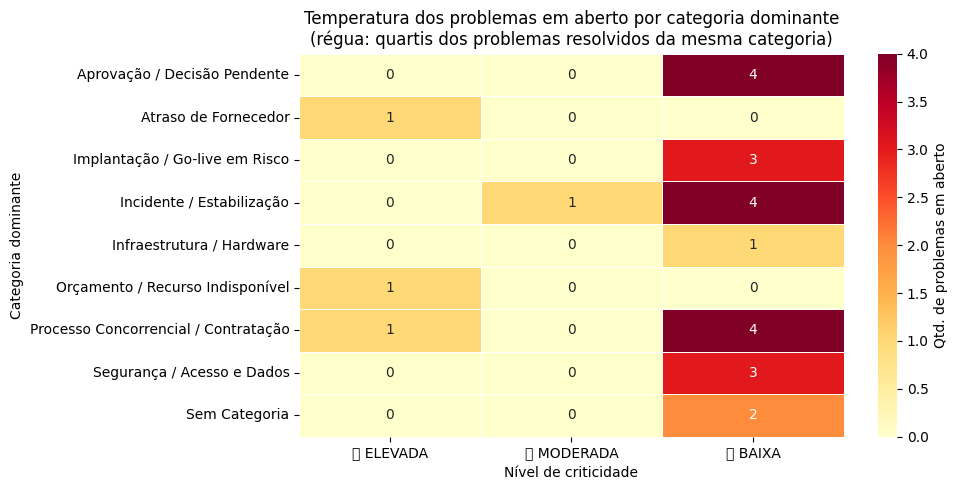


WATCHLIST — TOP 25 PROBLEMAS EM ABERTO
(temperatura = pior nível entre todas as categorias do problema)

# 1 | 🟡 ELEVADA
   Problema             : Ações de performance junto ao fornecedor Empresa C13 Projeto P39
   Categorias           : Atraso de Fornecedor
   Temperaturas         : 🟡 ELEVADA
   Em aberto desde      : jan/2026
   Tempo decorrido      : 4 meses
   Tempo médio esperado : 2.0 meses  (histórico categoria dominante)
   Situação             : 🔺 +2.0m acima do esperado

# 2 | 🟡 ELEVADA
   Problema             : Divisão do contrato visto o consumo por matéria e cada área assume o contrato especifico. PA: Gestão de custo CC.
   Categorias           : Processo Concorrencial / Contratação
   Temperaturas         : 🟡 ELEVADA
   Em aberto desde      : fev/2026
   Tempo decorrido      : 3 meses
   Tempo médio esperado : 1.2 meses  (histórico categoria dominante)
   Situação             : 🔺 +1.8m acima do esperado

# 3 | 🟡 ELEVADA
   Problema             : Projeto P4: Forecast BP- 

,Ranking,Temperatura,Categorias,Problema,Decorrido (meses),Esperado (meses),Situação,Menções
0,1,🟡 ELEVADA,Atraso de Fornecedor,Ações de performance junto ao fornecedor Empre...,4,2.000000,🔺 +2.0m acima do esperado,4
1,2,🟡 ELEVADA,Processo Concorrencial / Contratação,Divisão do contrato visto o consumo por matéri...,3,1.219512,🔺 +1.8m acima do esperado,6
2,3,🟡 ELEVADA,Orçamento / Recurso Indisponível | Infraestrut...,Projeto P4: Forecast BP- Baixa aderência de pa...,3,1.937500,🔺 +1.1m acima do esperado,5
3,4,🔵 MODERADA,Incidente / Estabilização | Gestão de Riscos,"Projeto P4: 28 itens de alto risco, mapeados e...",2,1.500000,➖ dentro do esperado,7
4,5,🟢 BAIXA,Implantação / Go-live em Risco | Segurança / A...,Service Desk - Reset de senha: Não execução do...,1,1.000000,➖ dentro do esperado,1
5,6,🟢 BAIXA,Segurança / Acesso e Dados,Service Desk - Reset de Senha: Impacto na comu...,1,1.000000,➖ dentro do esperado,1
6,7,🟢 BAIXA,Aprovação / Decisão Pendente | Negociação em A...,Projeto P8: Falta de aprovação da diretoria pa...,1,1.000000,➖ dentro do esperado,1
7,8,🟢 BAIXA,Aprovação / Decisão Pendente,"Projeto P6: Pauta sobre IA já em circulação, P...",1,1.000000,➖ dentro do esperado,1
8,9,🟢 BAIXA,Implantação / Go-live em Risco,"Projeto P7: Paralisação do programa por 2,5 se...",1,1.000000,➖ dentro do esperado,1
9,10,🟢 BAIXA,Aprovação / Decisão Pendente | Negociação em A...,Projeto P8: Falta de aprovação da diretoria pa...,1,1.000000,➖ dentro do esperado,1


In [59]:
# ============================================================================
# WATCHLIST DE CRITICIDADE — CATEGORIZAÇÃO + TEMPERATURA POR CATEGORIA
# ============================================================================
# Fluxo:
#   1. Cada problema recebe uma ou mais categorias temáticas, definidas por
#      palavras-chave encontradas no texto do representativo.
#   2. Os problemas são separados em RESOLVIDOS e EM ABERTO.
#   3. Os quartis de persistência (P25/P50/P75/P90) são calculados APENAS
#      com os resolvidos, por categoria. Fallback global se n < MIN_AMOSTRAS.
#   4. Cada problema em aberto é comparado contra os quartis históricos de
#      CADA UMA DAS SUAS CATEGORIAS e recebe a temperatura mais alta entre elas
#      (critério conservador — pior cenário vence).
#   5. Tempo médio esperado = média histórica dos resolvidos daquela combinação
#      categoria + temperatura. Desvio = tempo decorrido vs. esse esperado.

import re

MIN_AMOSTRAS = 5   # mínimo de resolvidos por categoria para usar quartis próprios

ultimo_periodo = df_result['periodo'].max()

# ── 1. Dicionário de categorias e palavras-chave ────────────────────────────
# Ordem não importa para matching (todas as categorias são avaliadas).
# As palavras-chave são comparadas em lowercase contra o texto do problema.

CATEGORIAS = {

    # ── Problemas com fornecedores / entregas externas ───────────────────────
    'Atraso de Fornecedor': [
        'atraso na entrega', 'atraso no desenvolvimento', 'atrasos recorrentes',
        'não conseguir concluir', 'entrega do trabalho', 'sla de entrega',
        'nova data limite', 'incerteza na entrega', 'nova previsão de entrega',
        'novo replanejamento', 'velocidade do squad', 'abaixo do planejado',
        'atraso no início', 'atraso nas correções', 'atraso sinalizado',
        'prometeu nova data', 'ações de performance', 'performance junto ao fornecedor',
        'fornecedor foi notificado', 'atraso na entrega das melhorias',
        'impacto no cronograma', 'pendências por parte do fornecedor',
        'entrega do escopo', 'atraso na implantação',
    ],

    # ── Contratos, licitações, seleção / troca de fornecedor ─────────────────
    'Processo Concorrencial / Contratação': [
        'processo concorrencial', 'aditivo contratual', 'troca do fornecedor',
        'avaliação de continuidade', 'negociar aditivo', 'contratação',
        'licitação', 'seleção de fornecedor', 'novo fornecedor',
        'avaliação de novo fornecedor', 'assinatura do contrato',
        'divergência de intenções', 'cláusulas contratuais', 'penalizações',
        'multas e limitações', 'assumir o contrato', 'divisão do contrato',
        'contrato global', 'deram a negativa para assumir', 'contrato de cabeamento',
        'gestão de custo cc', 'consumo por matéria',
    ],

    # ── Go-live, rollout, implantação em campo ───────────────────────────────
    'Implantação / Go-live em Risco': [
        'go-live', 'implantação', 'início da operação', 'rollout',
        'postergação', 'nova data para go-live', 'previsão de entrega',
        'início da implantação', 'nova data de entrega', 'data de go-live',
        'risco para o início', 'riscos devido a pendências',
        'cronograma de implantação', 'risco no cronograma',
        'não execução do desafio no prazo', 'phase-in postergado',
        'paralisação do programa',
    ],

    # ── Homologação, testes, validação técnica ───────────────────────────────
    'Homologação / Testes Pendentes': [
        'homologação', 'homologação não concluída', 'pentest',
        'validações das áreas técnicas', 'não foi possível rodar',
        'pendências de desenvolvimento', 'pendências de correções',
        'tentativa testes', 'testes e homologação',
    ],

    # ── Falta de verba, cancelamento por budget, aderência ───────────────────
    'Orçamento / Recurso Indisponível': [
        'não há orçamento', 'sem orçamento', 'disponibilidade de time',
        'projeto será cancelado', 'cancelado em 2024', 'cancelado em 2025',
        'incremento de orçamento', 'redução de 20% do custo',
        'redução de custo', 'custo de cloud', 'sem recurso',
        'necessidade de +r$', 'necessidade de r$',
        'baixa aderência', 'forecast bp', 'aderência de participação',
    ],

    # ── Produto/módulo suspenso aguardando substituição ou decisão ───────────
    'Produto Congelado / Descontinuado': [
        'produto congelado', 'congelado até substituição', 'descontinuado',
        'suspenso', 'substituição total', 'congelados', 'cancelar',
        'previsto apenas para 2025', 'previsto apenas para 2026',
        'congelado até', 'aguardando substituição',
    ],

    # ── Decisão, aprovação ou autorização pendente ───────────────────────────
    'Aprovação / Decisão Pendente': [
        'falta de aprovação', 'aguardando aprovação', 'aprovação da diretoria',
        'sem aprovação', 'pendente de aprovação', 'aguardando conclusão de análise',
        'aguardando decisão', 'aprovaram a pauta', 'pauta em circulação',
        'aguardando deliberação', 'aguardando autorização',
        'análise e aprovação', 'aprovação de setor',
    ],

    # ── Incidentes, estabilização, crises operacionais ───────────────────────
    'Incidente / Estabilização': [
        'plano de estabilização', 'sala de crise', 'salas de crise',
        'incidentes e exceções', 'tratados reativamente', 'exceções técnicas',
        'exceções recorrentes', 'correções no portal', 'pedido de ajuda',
        'problemas com impacto', 'impacto no processo', 'em tratamento',
        'em tratativa', 'itens de alto risco', 'estabilização em andamento',
        'problemas de ti', 'resolução de incidentes',
    ],

    # ── Segurança, acesso, dados, shadow IT ──────────────────────────────────
    'Segurança / Acesso e Dados': [
        'reset de senha', 'migração de autenticador', 'shadow it',
        'uso inadequado de dados', 'compartilhamento indevido',
        'migração de autenticação', 'adoção pelos usuários',
        'análise de risco', 'matriz de riscos', 'risco de normalizar exceção',
        'correção estrutural',
    ],

    # ── Gestão de riscos formal, mapeamento ──────────────────────────────────
    'Gestão de Riscos': [
        'itens de alto risco', 'mapeados e em tratativa', 'mapeamento de risco',
        'análise de risco ia', 'risco identificado', 'risco mapeado',
        'avaliação de risco', '28 itens de alto risco', 'riscos mapeados',
        'gestão de risco',
    ],

    # ── Infraestrutura física, hardware, rede, cloud ─────────────────────────
    'Infraestrutura / Hardware': [
        'câmeras', 'hardware', 'componentes', 'memória', 'placa de rede',
        'lente', 'instalação em campo', 'câmeras instaladas',
        'equipamento', 'servidor', 'cabeamento estruturado',
        'sustentação operacional', 'provisionamento de vms', 'oci',
        'on-premises', 'iac', 'infraestrutura de rede',
    ],

    # ── Negociação ativa sem bloqueio técnico / contratual ───────────────────
    'Negociação em Andamento': [
        'negociação em andamento', 'em negociação', 'negociar',
        'em discussão', 'acordo', 'proposta', 'em andamento com setor',
        'viabilizar o serviço', 'viabilizar o kt', 'em andamento',
    ],

}
CATEGORIA_SEM_MATCH = 'Sem Categoria'

# ── 2. Função de categorização (múltiplas categorias por problema) ──────────
def categorizar_problema(texto):
    """
    Retorna lista de categorias cujas palavras-chave foram encontradas no texto.
    Matching case-insensitive sobre o texto completo.
    Se nenhuma categoria bater, retorna ['Sem Categoria'].
    """
    if not isinstance(texto, str) or not texto.strip():
        return [CATEGORIA_SEM_MATCH]

    texto_lower = texto.lower()
    categorias_encontradas = []

    for categoria, keywords in CATEGORIAS.items():
        for kw in keywords:
            if kw in texto_lower:
                categorias_encontradas.append(categoria)
                break   # basta 1 keyword por categoria

    return categorias_encontradas if categorias_encontradas else [CATEGORIA_SEM_MATCH]

# ── 3. Aplicar categorização e separar resolvidos / em aberto ───────────────
df_base = df_resumo_area.copy()
df_base['ainda_ativo'] = df_base['fim'] >= ultimo_periodo
df_base['categorias'] = df_base['representativo'].apply(categorizar_problema)

df_resolvidos = df_base[~df_base['ainda_ativo']].copy()
df_abertos    = df_base[ df_base['ainda_ativo']].copy()

df_abertos['tempo_decorrido_meses'] = (
    (ultimo_periodo.year  - df_abertos['inicio'].dt.year) * 12 +
    (ultimo_periodo.month - df_abertos['inicio'].dt.month)
) + 1

# ── 4. Explodir por categoria (1 linha por categoria de cada problema) ───────
# Resolvidos: base para calcular quartis
df_res_explodido = df_resolvidos.explode('categorias').rename(
    columns={'categorias': 'categoria'}
)

# ── 5. Limiares de temperatura por categoria (base: resolvidos) ──────────────
# Metodologia: limiares ABSOLUTOS em meses, derivados do comportamento real
# dos problemas resolvidos daquela categoria.
#
# Por quê não usar quartis?
#   A distribuição de persistência é fortemente assimétrica (skew > 4):
#   ~80% dos problemas resolvem em 1 mês. Com isso, P25≈P50≈P75≈1 mês
#   e qualquer coisa com 2+ meses bate P90 → tudo vira CRÍTICA.
#
# Solução: limiares fixos com significado de negócio, calibrados na escala
# real do corpus (máx 9 meses, média 1.2 meses, crônico = 3 meses):
#
#   🟢 BAIXA    : 1 mês   — padrão normal (maioria resolve aqui)
#   🔵 MODERADA : 2 meses — passou do padrão, ainda aceitável
#   🟡 ELEVADA  : 3 meses — crônico (mesmo critério da análise temporal)
#   🟠 ALTA     : 5 meses — persistente e resistente
#   🔴 CRÍTICA  : ≥6 meses — casos extremos do histórico
#
# Segundo eixo: volume de menções acumuladas eleva a temperatura em 1 nível
# quando mencoes > LIMIAR_MENCOES (problema recorrente mesmo que recente).

LIMIARES = {
    'BAIXA':    1,   # até 1 mês
    'MODERADA': 2,   # até 2 meses
    'ELEVADA':  3,   # até 3 meses (crônico)
    'ALTA':     5,   # até 5 meses
    # CRÍTICA: >= 6 meses
}
LIMIAR_MENCOES = 8   # nº de menções que eleva temperatura em 1 nível

# Define todas_categorias before use
todas_categorias = df_res_explodido['categoria'].unique().tolist()

# Estatísticas descritivas por categoria (para auditoria e print)
stats_por_categoria = {}
for categoria in todas_categorias:
    tempos = df_res_explodido.loc[
        df_res_explodido['categoria'] == categoria, 'tempo_resolucao_meses'
    ].dropna()
    mencoes = df_res_explodido.loc[
        df_res_explodido['categoria'] == categoria, 'total_mencoes'
    ].dropna()
    n = len(tempos)
    stats_por_categoria[categoria] = {
        'n': n,
        'media': tempos.mean() if n > 0 else float('nan'),
        'mediana': tempos.median() if n > 0 else float('nan'),
        'max': tempos.max() if n > 0 else float('nan'),
        'p75': tempos.quantile(0.75) if n > 0 else float('nan'),
        'p90': tempos.quantile(0.90) if n > 0 else float('nan'),
        'mencoes_media': mencoes.mean() if n > 0 else float('nan'),
    }

# ── 6. Função de classificação por limiares absolutos + menções ──────────────
ORDEM_TEMPERATURA = ['🔴 CRÍTICA', '🟠 ALTA', '🟡 ELEVADA', '🔵 MODERADA', '🟢 BAIXA', '⚪ SEM DADOS']
SCORE_TEMPERATURA = {nivel: i for i, nivel in enumerate(reversed(ORDEM_TEMPERATURA))}
ESCALA_TEMP = ['🟢 BAIXA', '🔵 MODERADA', '🟡 ELEVADA', '🟠 ALTA', '🔴 CRÍTICA']

def classificar_temperatura(tempo, categoria, mencoes=0):
    """
    Classifica em 5 níveis usando limiares absolutos (meses) + ajuste por
    volume de menções acumuladas.
    - tempo    : meses de persistência (tempo_resolucao_meses ou decorrido)
    - categoria: não usada nos limiares (fixos), mas mantida para extensão futura
    - mencoes  : total_mencoes — eleva 1 nível se > LIMIAR_MENCOES
    """
    if pd.isna(tempo):
        return '⚪ SEM DADOS'

    if   tempo >= 6: nivel_base = '🔴 CRÍTICA'
    elif tempo >= 5: nivel_base = '🟠 ALTA'
    elif tempo >= 3: nivel_base = '🟡 ELEVADA'
    elif tempo >= 2: nivel_base = '🔵 MODERADA'
    else:            nivel_base = '🟢 BAIXA'

    # Elevar 1 nível por alto volume de menções (problema recorrente)
    if mencoes > LIMIAR_MENCOES and nivel_base != '🔴 CRÍTICA':
        idx_atual = ESCALA_TEMP.index(nivel_base)
        nivel_base = ESCALA_TEMP[min(idx_atual + 1, len(ESCALA_TEMP) - 1)]

    return nivel_base

# Classifica resolvidos com suas menções reais
df_res_explodido['temperatura'] = df_res_explodido.apply(
    lambda r: classificar_temperatura(
        r['tempo_resolucao_meses'], r['categoria'], r.get('total_mencoes', 0)
    ), axis=1
)

# ── Print de auditoria: resolvidos por categoria x temperatura ───────────────
print("=" * 70)
print("LIMIARES DE TEMPERATURA (limiares absolutos em meses)")
print("=" * 70)
print(f"  🟢 BAIXA    : < 2 meses")
print(f"  🔵 MODERADA : 2–3 meses")
print(f"  🟡 ELEVADA  : 3–5 meses  (crônico)")
print(f"  🟠 ALTA     : 5–6 meses")
print(f"  🔴 CRÍTICA  : ≥ 6 meses")
print(f"  + Eleva 1 nível se menções acumuladas > {LIMIAR_MENCOES}")

print("\n" + "=" * 70)
print("DISTRIBUIÇÃO DOS RESOLVIDOS POR CATEGORIA × TEMPERATURA")
print("(base histórica usada para calibrar o watchlist)")
print("=" * 70)

cols_temp = [t for t in ORDEM_TEMPERATURA if t != '⚪ SEM DADOS']
tabela_auditoria = (
    pd.crosstab(df_res_explodido['categoria'], df_res_explodido['temperatura'])
    .reindex(columns=[c for c in cols_temp if c in df_res_explodido['temperatura'].values], fill_value=0)
    .fillna(0)
    .astype(int)
)

# Adicionar colunas de stats
for cat in tabela_auditoria.index:
    s = stats_por_categoria.get(cat, {})

tabela_auditoria['Total resolvidos'] = tabela_auditoria.sum(axis=1)

# Print formatado
header = f"  {'Categoria':<38}" + "".join(f"{c[-7:]:>10}" for c in tabela_auditoria.columns)
print(header)
print("  " + "-" * (38 + 10 * len(tabela_auditoria.columns)))
for cat, row in tabela_auditoria.iterrows():
    s = stats_por_categoria.get(cat, {})
    media_str = f"  média={s.get('media', 0):.1f}m  max={s.get('max', 0):.0f}m"
    linha = f"  {cat:<38}" + "".join(f"{int(v):>10}" for v in row.values)
    print(linha + media_str)

# ── 7. Tempo médio esperado por categoria + temperatura ──────────────────────
tempo_medio_ref = (
    df_res_explodido
    .groupby(['categoria', 'temperatura'])['tempo_resolucao_meses']
    .mean()
)

def tempo_esperado_ref(categoria, temperatura):
    chave = (categoria, temperatura)
    if chave in tempo_medio_ref.index:
        return tempo_medio_ref.loc[chave]
    # fallback: média geral da categoria
    media_cat = df_res_explodido.loc[
        df_res_explodido['categoria'] == categoria, 'tempo_resolucao_meses'
    ].mean()
    return media_cat

# ── 8. Classificar cada problema em aberto ───────────────────────────────────
# Para cada problema: avalia todas as suas categorias, pega a temperatura
# mais quente (score mais alto) → critério conservador.

def classificar_problema_aberto(row):
    tempo = row['tempo_decorrido_meses']
    resultados = []
    for cat in row['categorias']:
        temp = classificar_temperatura(tempo, cat, row.get('total_mencoes', 0))
        esperado = tempo_esperado_ref(cat, temp)
        desvio   = tempo - esperado if pd.notna(esperado) else float('nan')
        resultados.append({
            'categoria': cat,
            'temperatura': temp,
            'score': SCORE_TEMPERATURA.get(temp, 0),
            'tempo_esperado_meses': esperado,
            'desvio_meses': desvio,
        })
    # ordenar por score (mais quente primeiro)
    resultados.sort(key=lambda x: x['score'], reverse=True)

    # temperatura dominante = a mais quente
    top = resultados[0]
    todas_categorias_str  = ' | '.join(r['categoria']   for r in resultados)
    todas_temperaturas_str = ' | '.join(r['temperatura'] for r in resultados)

    return pd.Series({
        'temperatura':           top['temperatura'],
        'temperatura_score':     top['score'],
        'categoria_dominante':   top['categoria'],
        'todas_categorias':      todas_categorias_str,
        'todas_temperaturas':    todas_temperaturas_str,
        'tempo_esperado_meses':  top['tempo_esperado_meses'],
        'desvio_meses':          top['desvio_meses'],
    })

classificacao = df_abertos.apply(classificar_problema_aberto, axis=1)
df_abertos = pd.concat([df_abertos, classificacao], axis=1)

def status_desvio(desvio):
    if pd.isna(desvio): return '— sem referência'
    if desvio >  0.5:   return f'🔺 {desvio:+.1f}m acima do esperado'
    if desvio < -0.5:   return f'🔻 {desvio:+.1f}m abaixo do esperado'
    return '➖ dentro do esperado'

df_abertos['status_desvio'] = df_abertos['desvio_meses'].apply(status_desvio)

# ── 9. Seleção do Top 25 (watchlist) ────────────────────────────────────────
df_watchlist = (
    df_abertos
    .sort_values(
        by=['temperatura_score', 'desvio_meses', 'tempo_decorrido_meses'],
        ascending=[False, False, False]
    )
    .head(25)
    .reset_index(drop=True)
)
df_watchlist.insert(0, 'ranking', range(1, len(df_watchlist) + 1))

# ── 10. Visão consolidada ─────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("DISTRIBUIÇÃO DE TEMPERATURA — PROBLEMAS EM ABERTO")
print("=" * 70)
dist = (
    df_abertos['temperatura']
    .value_counts()
    .reindex(ORDEM_TEMPERATURA)
    .dropna()
)
total = dist.sum()
for nivel, qtd in dist.items():
    print(f"  {nivel:<14}: {int(qtd):>4}  ({qtd/total:.1%})")

# Heatmap: categoria dominante × temperatura
heatmap = (
    pd.crosstab(df_abertos['categoria_dominante'], df_abertos['temperatura'])
    .reindex(columns=[c for c in ORDEM_TEMPERATURA if c in df_abertos['temperatura'].values])
    .fillna(0)
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Qtd. de problemas em aberto'}
)
plt.title(
    'Temperatura dos problemas em aberto por categoria dominante\n'
    '(régua: quartis dos problemas resolvidos da mesma categoria)'
)
plt.xlabel('Nível de criticidade')
plt.ylabel('Categoria dominante')
plt.tight_layout()
plt.show()

# ── 11. Watchlist detalhada — Top 25 ─────────────────────────────────────────
print("\n" + "=" * 70)
print("WATCHLIST — TOP 25 PROBLEMAS EM ABERTO")
print("(temperatura = pior nível entre todas as categorias do problema)")
print("=" * 70)

MESES_ABREV = {
    1:'jan',2:'fev',3:'mar',4:'abr',5:'mai',6:'jun',
    7:'jul',8:'ago',9:'set',10:'out',11:'nov',12:'dez'
}

for _, row in df_watchlist.iterrows():
    inicio_fmt = (
        f"{MESES_ABREV.get(row['inicio'].month,'?')}/{row['inicio'].year}"
        if pd.notna(row.get('inicio')) else "?"
    )
    esp_fmt = (
        f"{row['tempo_esperado_meses']:.1f} meses"
        if pd.notna(row['tempo_esperado_meses']) else "sem referência histórica"
    )

    print(f"\n#{row['ranking']:>2} | {row['temperatura']}")
    print(f"   Problema             : {row['representativo']}")
    print(f"   Categorias           : {row['todas_categorias']}")
    print(f"   Temperaturas         : {row['todas_temperaturas']}")
    print(f"   Em aberto desde      : {inicio_fmt}")
    print(f"   Tempo decorrido      : {row['tempo_decorrido_meses']:.0f} meses")
    print(f"   Tempo médio esperado : {esp_fmt}  (histórico categoria dominante)")
    print(f"   Situação             : {row['status_desvio']}")

# ── 12. Tabela resumo exportável ─────────────────────────────────────────────
tabela_watchlist = df_watchlist[[
    'ranking', 'temperatura', 'todas_categorias', 'representativo',
    'tempo_decorrido_meses', 'tempo_esperado_meses', 'status_desvio', 'total_mencoes'
]].rename(columns={
    'ranking':                'Ranking',
    'temperatura':            'Temperatura',
    'todas_categorias':       'Categorias',
    'representativo':         'Problema',
    'tempo_decorrido_meses':  'Decorrido (meses)',
    'tempo_esperado_meses':   'Esperado (meses)',
    'status_desvio':          'Situação',
    'total_mencoes':          'Menções',
})

tabela_watchlist

# **Avaliação dos clusters**

---



In [60]:
# Verificação dos TOP 10 clusters
def verificacao_clusters(cluster_id):
  'Essa função imprime o texto de todos os elementos de um determinado cluster'
  df_cluster_espec = df_so_problemas[df_so_problemas['cluster'] == cluster_id]
  print(f"\nCluster {df_cluster_espec['cluster'].iloc[0]} - {len(df_cluster_espec)} registros\n")
  for _, row in df_cluster_espec.iterrows():
    print(f"[{row['cluster_prob']:.2f}] {row['texto']}")
  print("="*130)

for _, row in top10.iterrows():
  verificacao_clusters(row['cluster'])


Cluster 37 - 14 registros

[0.88] Projeto P67 – Requalificação Projeto P36 2.0 Módulo Expedição (eliminação Projeto P78): Nova postergação do go-live no Localidade L3 de 21/10 para 18/11.
[0.98] Requalificação Projeto P36 2.0 Módulo Expedição (eliminação Projeto P78): Nova data para go-live no Localidade L3 previsto para o dia 21/10/2024, porém com riscos devido a pendências de desenvolvimento, testes e homologação. Risco para o início da operação Setor A14 no Localidade L3 ainda em 2024 (eliminação do Projeto P78);
[0.88] Requalificação Projeto P36 2.0 Módulo Expedição (eliminação Projeto P78): Nova data para go-live no Localidade L3 previsto para o dia 21/10/2024, porém com riscos devido a pendências de desenvolvimento, testes e homologação. Risco para o início da operação Setor A14 no Localidade L3 ainda em 2024 (eliminação do Projeto P78);
[0.89] Projeto P10 (Empresa C26): Incerteza na entrega do trabalho pela Empresa C26. Empresa C26 prometeu nova data limite para entrega do esco

# **Análise Gráfica**

---



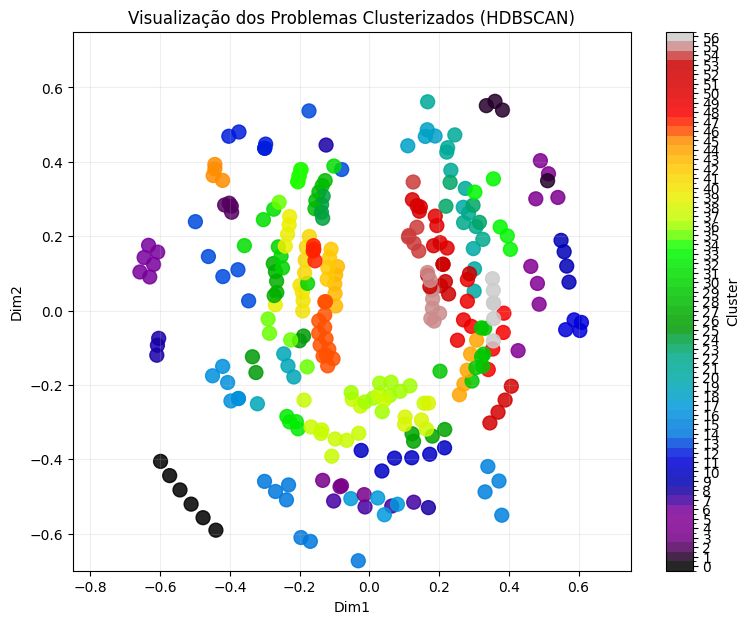

In [61]:
# Verificação gráfica dos clusters
mask = (df_so_problemas['cluster'] != -1)
df_plot = df_so_problemas[mask].copy()
dist_plot = dist_combinada[np.ix_(mask, mask)]

mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    random_state=42,
    normalized_stress='auto'
)

coords = mds.fit_transform(dist_plot)

df_plot['x'] = coords[:, 0]
df_plot['y'] = coords[:, 1]

exibir_cluster_unico = -1
if exibir_cluster_unico != -1:
  df_plot = df_plot[
      df_plot['cluster'] == exibir_cluster_unico
  ].copy()

clusters_unicos = sorted(df_plot['cluster'].unique())
cluster_map = {cluster: idx for idx, cluster in enumerate(clusters_unicos)}

df_plot['cluster_idx'] = df_plot['cluster'].map(cluster_map)

n_clusters = len(clusters_unicos)

cores = plt.cm.nipy_spectral(np.linspace(0, 1, n_clusters))
cmap = ListedColormap(cores)

norm = BoundaryNorm(
    boundaries=np.arange(-0.5, n_clusters + 0.5, 1),
    ncolors=n_clusters
    )

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    df_plot['x'],
    df_plot['y'],
    c=df_plot['cluster'],
    cmap=cmap,
    norm=norm,
    s=100,
    alpha=0.85
)
cbar = plt.colorbar(sc, ticks=np.arange(n_clusters))
cbar.ax.set_yticklabels(clusters_unicos)
cbar.set_label('Cluster')

plt.xlim(-0.85, 0.75)
plt.ylim(-0.7, 0.75)

plt.title('Visualização dos Problemas Clusterizados (HDBSCAN)')
plt.xlabel('Dim1')
plt.ylabel('Dim2')
plt.grid(alpha=0.2)

plt.show()